In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from textblob import TextBlob
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor

## 1. Load and Inspect the Data

In [3]:
# Load gold prices
gold = pd.read_csv('Gold HistoricalData_1628818323325.csv')
gold['Date'] = pd.to_datetime(gold['Date'], format='%m/%d/%Y')
gold = gold.sort_values('Date').reset_index(drop=True)

print(f"Shape: {gold.shape}")
print(f"Date range: {gold['Date'].min().date()} to {gold['Date'].max().date()}")
print(f"Price range: ${gold['Close/Last'].min():.1f} to ${gold['Close/Last'].max():.1f}")
gold.head()

Shape: (2559, 6)
Date range: 2011-08-12 to 2021-08-12
Price range: $1049.6 to $2069.4


,Date,Close/Last,Volume,Open,High,Low
0,2011-08-12,1742.6,188418.0,1733.0,1770.9,1725.9
1,2011-08-15,1758.0,110191.0,1741.3,1767.8,1730.9
2,2011-08-16,1785.0,148533.0,1780.8,1789.2,1763.6
3,2011-08-17,1793.8,125321.0,1790.0,1797.6,1781.8
4,2011-08-18,1822.0,197469.0,1818.0,1830.6,1786.8


In [4]:
# Load news headlines
news = pd.read_csv('gold-dataset-sinha-khandait.csv')

# Handle mixed date formats
news['Date'] = pd.to_datetime(news['Dates'], format='mixed', dayfirst=True, errors='coerce')
news = news.dropna(subset=['Date'])

print(f"Shape: {news.shape}")
print(f"Date range: {news['Date'].min().date()} to {news['Date'].max().date()}")
print(f"Unique dates: {news['Date'].nunique()}")
print(f"\nSample headlines:")
for i in range(5):
    print(f"  {news.iloc[i]['Date'].date()} | {news.iloc[i]['News'][:80]}")

Shape: (10405, 4)
Date range: 2000-02-15 to 2019-02-01
Unique dates: 3672

Sample headlines:
  2016-01-28 | april gold down 20 cents to settle at $1,116.10/oz
  2017-09-13 | gold suffers third straight daily decline
  2016-07-26 | Gold futures edge up after two-session decline
  2018-02-28 | dent research : is gold's day in the sun coming soon?
  2017-09-06 | Gold snaps three-day rally as Trump, lawmakers reach debt-ceiling deal


## 2. Exploratory Data Analysis

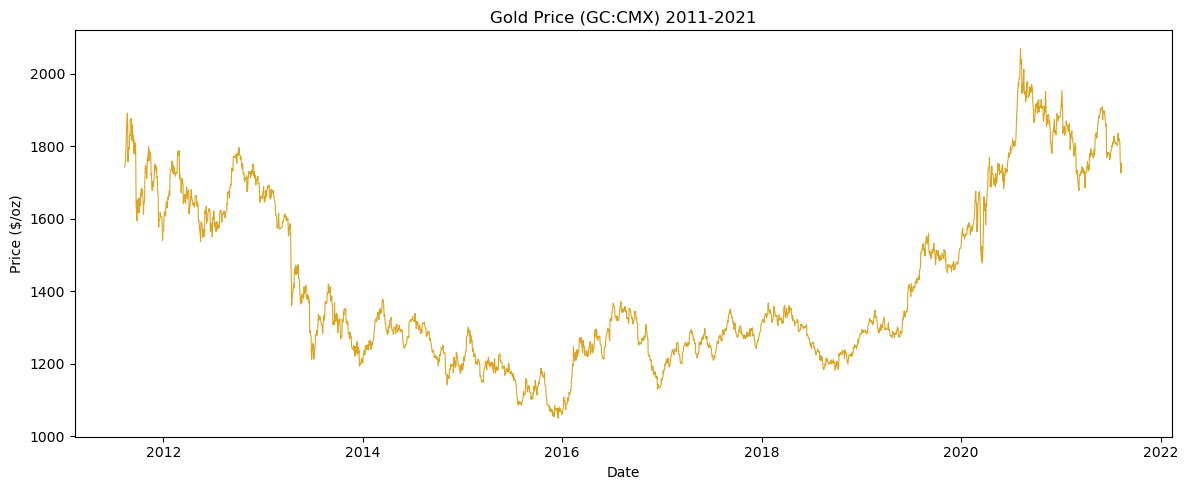

Mean price:   $1423.54
Median price: $1319.00
Std dev:      $236.51


In [5]:
# Gold price over time
plt.figure(figsize=(12, 5))
plt.plot(gold['Date'], gold['Close/Last'], color='goldenrod', linewidth=0.8)
plt.title('Gold Price (GC:CMX) 2011-2021')
plt.xlabel('Date')
plt.ylabel('Price ($/oz)')
plt.tight_layout()
plt.show()


print(f"Mean price:   ${gold['Close/Last'].mean():.2f}")
print(f"Median price: ${gold['Close/Last'].median():.2f}")
print(f"Std dev:      ${gold['Close/Last'].std():.2f}")

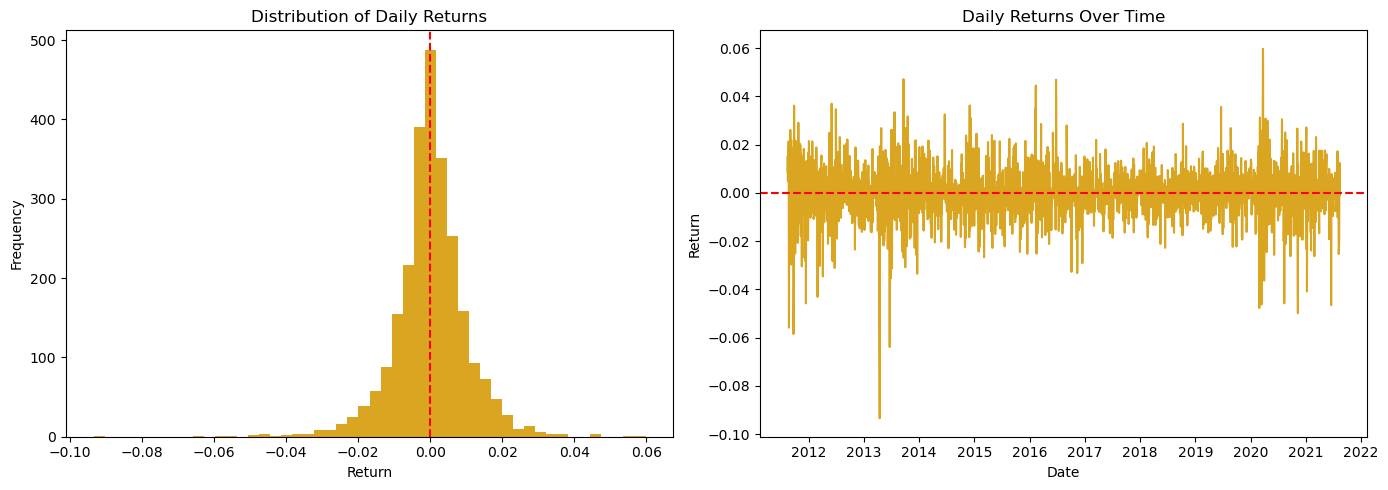

Mean daily return: 0.0056%
Std daily return:  1.0386%


In [6]:
# Daily returns
gold['Return'] = gold['Close/Last'].pct_change()
gold['Log_Return'] = np.log(gold['Close/Last'] / gold['Close/Last'].shift(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(gold['Return'].dropna(), color='goldenrod', bins=50)
axes[0].set_title('Distribution of Daily Returns')
axes[0].set_xlabel('Return')
axes[0].set_ylabel('Frequency')
axes[0].axvline(0, linestyle='--', color='red')

axes[1].plot(gold['Date'], gold['Return'], color='goldenrod')
axes[1].set_title('Daily Returns Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Return')
axes[1].axhline(0, linestyle='--', color='red')

plt.tight_layout()
plt.show()

print(f"Mean daily return: {gold['Return'].mean()*100:.4f}%")
print(f"Std daily return:  {gold['Return'].std()*100:.4f}%")

## 3. NLP Feature Engineering


In [7]:
# Sentiment analysis using TextBlob
news['Polarity'] = news['News'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
news['Subjectivity'] = news['News'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

print("Sentiment Polarity distribution:")
print(news['Polarity'].describe().round(4))
print(f"\nSentiment Subjectivity distribution:")
print(news['Subjectivity'].describe().round(4))

Sentiment Polarity distribution:
count    10405.0000
mean         0.0165
std          0.1752
min         -1.0000
25%          0.0000
50%          0.0000
75%          0.0022
max          1.0000
Name: Polarity, dtype: float64

Sentiment Subjectivity distribution:
count    10405.0000
mean         0.2047
std          0.2509
min          0.0000
25%          0.0000
50%          0.0000
75%          0.4000
max          1.0000
Name: Subjectivity, dtype: float64


In [8]:
# Past vs Future classification
past_keywords = ['fell', 'dropped', 'declined', 'lost', 'slid', 'tumbled', 
                 'gained', 'rose', 'climbed', 'settled', 'ended', 'closed',
                 'was', 'were', 'had', 'posted', 'recorded', 'hit']
future_keywords = ['will', 'could', 'may', 'might', 'expected', 'forecast', 
                   'outlook', 'predict', 'ahead', 'coming', 'should', 'likely',
                   'potential', 'set to', 'poised']

news['Is_Past'] = news['News'].str.lower().str.contains('|'.join(past_keywords), na=False).astype(int)
news['Is_Future'] = news['News'].str.lower().str.contains('|'.join(future_keywords), na=False).astype(int)

print(f"Headlines about past movement: {news['Is_Past'].sum()} ({news['Is_Past'].mean()*100:.1f}%)")
print(f"Headlines about future movement: {news['Is_Future'].sum()} ({news['Is_Future'].mean()*100:.1f}%)")
print(f"Headlines about both: {((news['Is_Past']==1) & (news['Is_Future']==1)).sum()}")
print(f"Headlines about neither: {((news['Is_Past']==0) & (news['Is_Future']==0)).sum()}")

Headlines about past movement: 329 (3.2%)
Headlines about future movement: 825 (7.9%)
Headlines about both: 30
Headlines about neither: 9281


In [9]:
# Additional NLP features
news['Word_Count'] = news['News'].str.split().str.len()
news['Has_Price'] = news['News'].str.contains(r'\$[0-9]', na=False).astype(int)

print(f"Average word count: {news['Word_Count'].mean():.1f}")
print(f"Headlines with price mention: {news['Has_Price'].sum()} ({news['Has_Price'].mean()*100:.1f}%)")

Average word count: 9.0
Headlines with price mention: 2498 (24.0%)


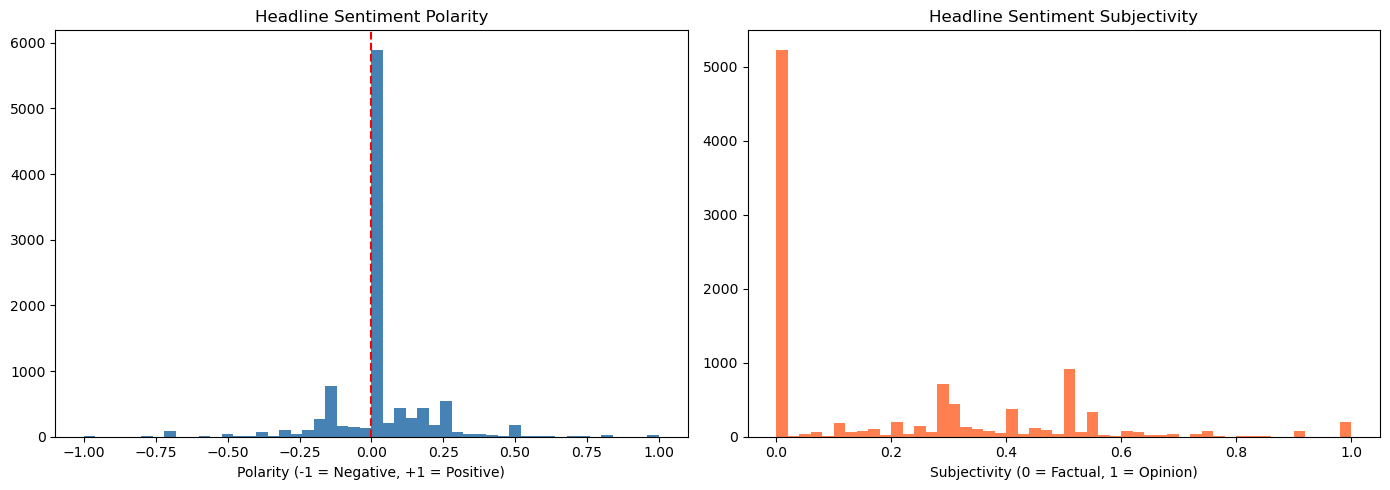

In [10]:
# Visualize sentiment distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(news['Polarity'], bins=50, color='steelblue')
axes[0].set_title('Headline Sentiment Polarity')
axes[0].set_xlabel('Polarity (-1 = Negative, +1 = Positive)')
axes[0].axvline(0, linestyle='--', color='red')

axes[1].hist(news['Subjectivity'], bins=50, color='coral')
axes[1].set_title('Headline Sentiment Subjectivity')
axes[1].set_xlabel('Subjectivity (0 = Factual, 1 = Opinion)')

plt.tight_layout()
plt.show()

## 4. Aggregate News by Day and Merge with Prices

In [11]:
# Aggregate news features by day
daily_news = news.groupby('Date').agg(
    Avg_Polarity=('Polarity', 'mean'),
    Avg_Subjectivity=('Subjectivity', 'mean'),
    Max_Polarity=('Polarity', 'max'),
    Min_Polarity=('Polarity', 'min'),
    Polarity_Std=('Polarity', 'std'),
    Pct_Past=('Is_Past', 'mean'),
    Pct_Future=('Is_Future', 'mean'),
    Headline_Count=('News', 'count'),
    Avg_Word_Count=('Word_Count', 'mean'),
    Pct_Has_Price=('Has_Price', 'mean'),
).reset_index()

# Fill std NaN (days with 1 headline)
daily_news['Polarity_Std'] = daily_news['Polarity_Std'].fillna(0)

print(f"Daily news aggregated: {len(daily_news)} unique days")
daily_news.head()

Daily news aggregated: 3672 unique days


,Date,Avg_Polarity,Avg_Subjectivity,Max_Polarity,Min_Polarity,Polarity_Std,Pct_Past,Pct_Future,Headline_Count,Avg_Word_Count,Pct_Has_Price
0,2000-02-15,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,1,5.0,0.0
1,2000-02-17,0.000000,0.050000,0.000000,0.000000,0.0,0.0,0.0,1,6.0,0.0
2,2000-03-24,0.000000,0.333333,0.000000,0.000000,0.0,0.0,0.0,1,7.0,0.0
3,2000-04-27,0.166667,0.500000,0.166667,0.166667,0.0,0.0,0.0,1,6.0,0.0
4,2000-05-04,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1,7.0,0.0


In [12]:
# Merge with gold prices
df = pd.merge(gold, daily_news, on='Date', how='inner')

print(f"Merged dataset: {len(df)} trading days with news")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

# Drop rows with missing values
df = df.dropna()
print(f"\nFinal dataset: {len(df)} rows")

Merged dataset: 1756 trading days with news
Date range: 2011-08-12 to 2019-02-01

Missing values:
Volume        27
Return         1
Log_Return     1
dtype: int64

Final dataset: 1728 rows


## 5. Price-Based Feature Engineering

In [13]:
# Target: next-day return (predict tomorrow's return using today's news + price)
df['Target_Return_1d'] = df['Close/Last'].shift(-1) / df['Close/Last'] - 1

# Target: 5-day forward return
df['Target_Return_5d'] = df['Close/Last'].shift(-5) / df['Close/Last'] - 1

# Price-based features
df['MA_5'] = df['Close/Last'].rolling(5).mean()
df['MA_20'] = df['Close/Last'].rolling(20).mean()
df['MA_Ratio'] = df['MA_5'] / df['MA_20']
df['Volatility_5d'] = df['Return'].rolling(5).std()
df['Volatility_20d'] = df['Return'].rolling(20).std()
df['Momentum_5d'] = df['Close/Last'] / df['Close/Last'].shift(5) - 1
df['Momentum_20d'] = df['Close/Last'] / df['Close/Last'].shift(20) - 1
df['Volume_MA_Ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()
df['Daily_Range'] = (df['High'] - df['Low']) / df['Close/Last']

# Drop rows with NaN from rolling calculations
df = df.dropna()
print(f"Final dataset after feature engineering: {len(df)} rows")
print(f"\nFeatures available: {df.columns.tolist()}")

Final dataset after feature engineering: 1703 rows

Features available: ['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low', 'Return', 'Log_Return', 'Avg_Polarity', 'Avg_Subjectivity', 'Max_Polarity', 'Min_Polarity', 'Polarity_Std', 'Pct_Past', 'Pct_Future', 'Headline_Count', 'Avg_Word_Count', 'Pct_Has_Price', 'Target_Return_1d', 'Target_Return_5d', 'MA_5', 'MA_20', 'MA_Ratio', 'Volatility_5d', 'Volatility_20d', 'Momentum_5d', 'Momentum_20d', 'Volume_MA_Ratio', 'Daily_Range']


## 6. Prepare Data for Modeling

In [14]:
# Select features
nlp_features = ['Avg_Polarity', 'Avg_Subjectivity', 'Max_Polarity', 'Min_Polarity', 
                'Polarity_Std', 'Pct_Past', 'Pct_Future', 'Headline_Count', 
                'Avg_Word_Count', 'Pct_Has_Price']

price_features = ['Return', 'MA_Ratio', 'Volatility_5d', 'Volatility_20d',
                  'Momentum_5d', 'Momentum_20d', 'Volume_MA_Ratio', 'Daily_Range']

all_features = nlp_features + price_features

target = 'Target_Return_5d'

X = df[all_features]
y = df[target]

print(f"Features: {len(all_features)} ({len(nlp_features)} NLP + {len(price_features)} price)")
print(f"Target: {target}")
print(f"Samples: {len(X)}")
print(f"\nTarget distribution:")
print(y.describe().round(6))

Features: 18 (10 NLP + 8 price)
Target: Target_Return_5d
Samples: 1703

Target distribution:
count    1703.000000
mean       -0.000628
std         0.023011
min        -0.123229
25%        -0.014216
50%        -0.000241
75%         0.014020
max         0.083576
Name: Target_Return_5d, dtype: float64


In [15]:
# Train/test split (80/20, time-series aware — no shuffle)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Train: {X_train.shape} ({df['Date'].iloc[0].date()} to {df['Date'].iloc[split_idx-1].date()})")
print(f"Test:  {X_test.shape} ({df['Date'].iloc[split_idx].date()} to {df['Date'].iloc[-1].date()})")

Train: (1362, 18) (2011-09-15 to 2017-08-28)
Test:  (341, 18) (2017-08-29 to 2019-01-24)


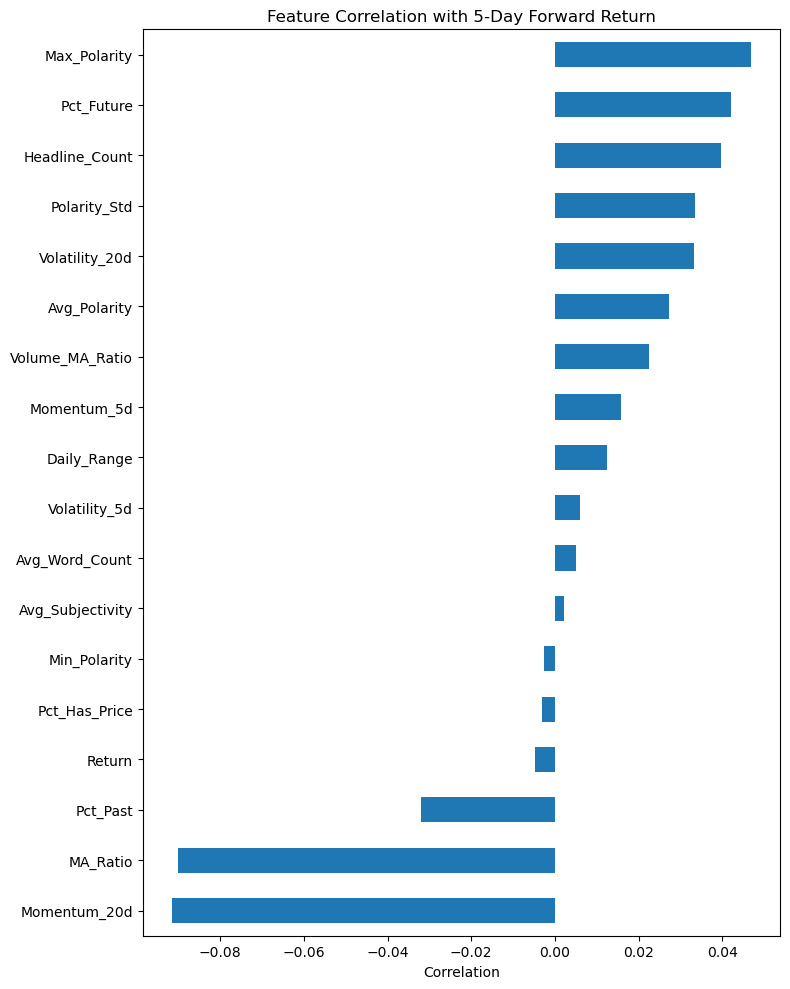

In [16]:
# Correlation of features with target
plt.figure(figsize=(8, 10))
corr_with_target = X_train.corrwith(y_train).sort_values()
corr_with_target.plot(kind='barh')
plt.title('Feature Correlation with 5-Day Forward Return')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

## 7. Model 1: OLS Regression


In [17]:
X_train_ols = sm.add_constant(X_train_scaled)
X_test_ols = sm.add_constant(X_test_scaled)

ols_model = sm.OLS(y_train, X_train_ols).fit()
results_robust = ols_model.get_robustcov_results(cov_type='HC0')
print(results_robust.summary())

                            OLS Regression Results                            
Dep. Variable:       Target_Return_5d   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     2.017
Date:                Thu, 02 Apr 2026   Prob (F-statistic):            0.00700
Time:                        22:51:52   Log-Likelihood:                 3120.7
No. Observations:                1362   AIC:                            -6203.
Df Residuals:                    1343   BIC:                            -6104.
Df Model:                          18                                         
Covariance Type:                  HC0                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0008      0.001  

In [18]:
y_pred_ols = ols_model.predict(X_test_ols)

r2_ols = r2_score(y_test, y_pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
mae_ols = mean_absolute_error(y_test, y_pred_ols)

print(f"OLS Test R²:  {r2_ols:.4f}")
print(f"OLS RMSE:     {rmse_ols:.6f}")
print(f"OLS MAE:      {mae_ols:.6f}")

OLS Test R²:  -0.0738
OLS RMSE:     0.014410
OLS MAE:      0.011511


## 8. Model 2: Random Forest

In [19]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

rf_gs = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=kf, scoring='r2')
rf_gs.fit(X_train_scaled, y_train)

print(f"Best params: {rf_gs.best_params_}")
print(f"Best CV R²:  {rf_gs.best_score_:.4f}")

y_pred_rf = rf_gs.predict(X_test_scaled)

print(f"\nRandom Forest Test R²:  {r2_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.6f}")
print(f"Random Forest MAE:      {mean_absolute_error(y_test, y_pred_rf):.6f}")

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²:  0.1176

Random Forest Test R²:  -0.2752
Random Forest RMSE:     0.015704
Random Forest MAE:      0.012511


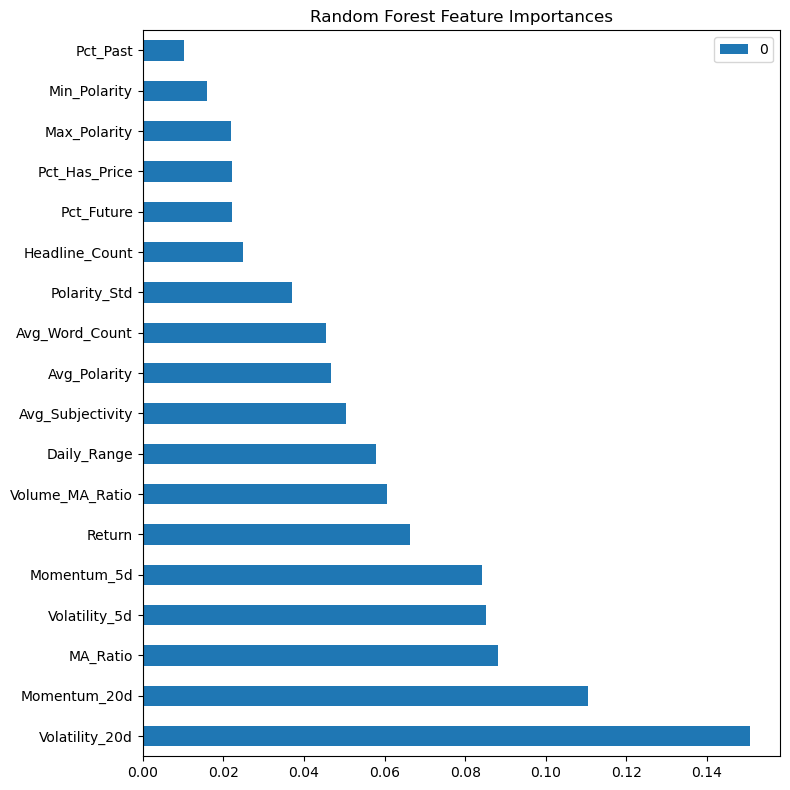

In [20]:
# Feature importance
feature_importances = pd.DataFrame(
    rf_gs.best_estimator_.feature_importances_, 
    index=X_train.columns
).sort_values(by=0, ascending=False)

feature_importances.plot(kind='barh', figsize=(8, 8))
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

## 9. Model 3: AdaBoost

In [21]:
ada_model = AdaBoostRegressor(n_estimators=100, random_state=42)
ada_model.fit(X_train_scaled, y_train)

y_pred_ada = ada_model.predict(X_test_scaled)

print(f"AdaBoost Test R²:  {r2_score(y_test, y_pred_ada):.4f}")
print(f"AdaBoost RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_ada)):.6f}")
print(f"AdaBoost MAE:      {mean_absolute_error(y_test, y_pred_ada):.6f}")

AdaBoost Test R²:  -0.2255
AdaBoost RMSE:     0.015395
AdaBoost MAE:      0.012266


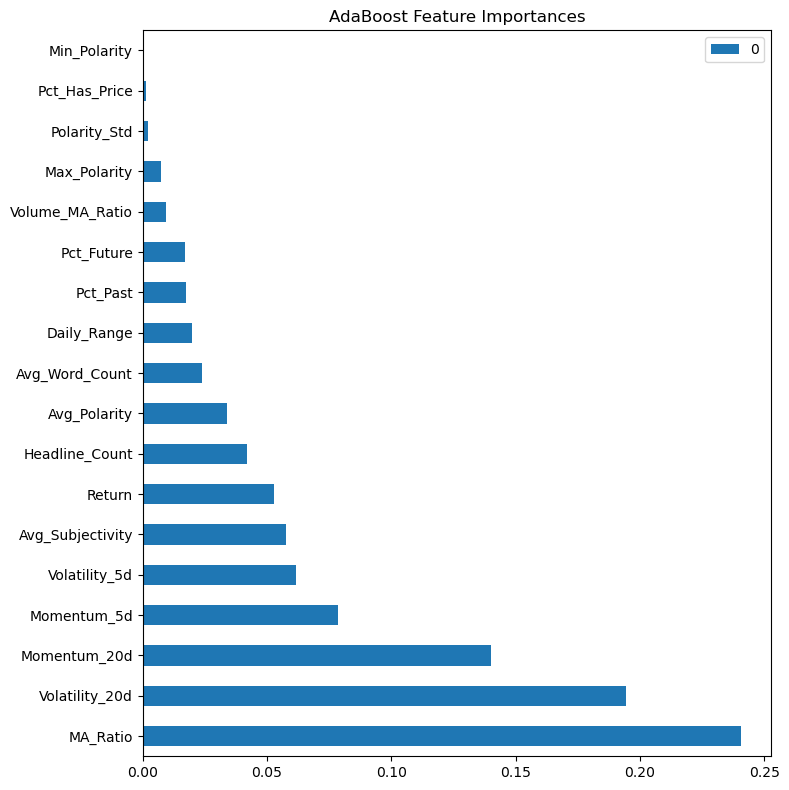

In [22]:
# AdaBoost feature importance
feature_importances_ada = pd.DataFrame(
    ada_model.feature_importances_, 
    index=X_train.columns
).sort_values(by=0, ascending=False)

feature_importances_ada.plot(kind='barh', figsize=(8, 8))
plt.title('AdaBoost Feature Importances')
plt.tight_layout()
plt.show()

## 9b. Model 4: XGBoost

In [23]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100, 
    max_depth=3,           # Shallow trees to prevent overfitting
    learning_rate=0.05,    # Small learning rate for gradual learning
    subsample=0.8,         # Use 80% of data per tree (reduces overfitting)
    colsample_bytree=0.8,  # Use 80% of features per tree
    reg_alpha=0.1,         # L1 regularization
    reg_lambda=1.0,        # L2 regularization
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

print(f"XGBoost Test R²:  {r2_score(y_test, y_pred_xgb):.4f}")
print(f"XGBoost RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.6f}")
print(f"XGBoost MAE:      {mean_absolute_error(y_test, y_pred_xgb):.6f}")

XGBoost Test R²:  -0.1405
XGBoost RMSE:     0.014851
XGBoost MAE:      0.011741


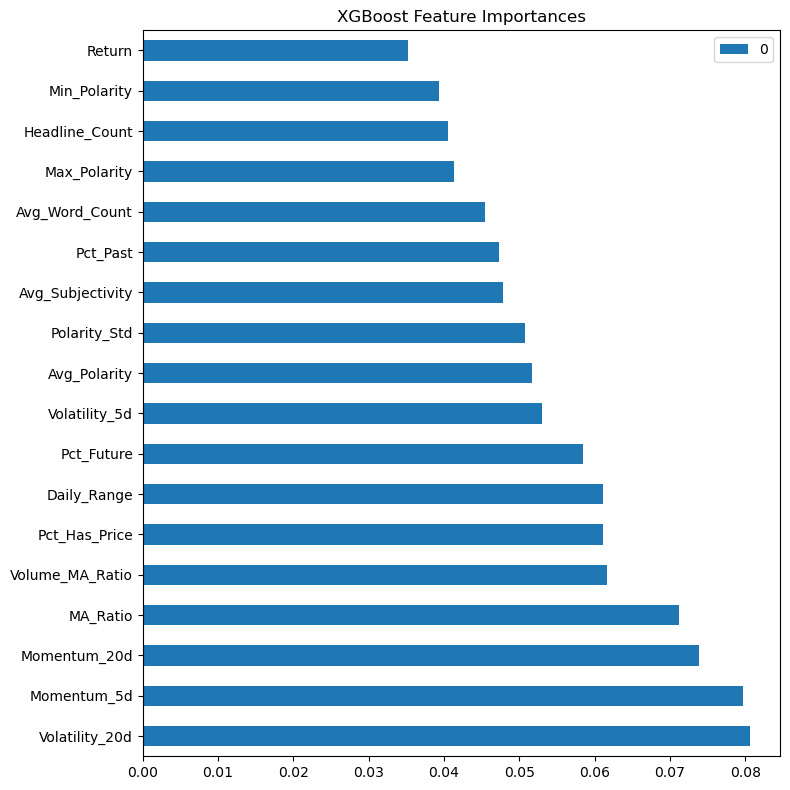

In [24]:
# XGBoost feature importance
xgb_imp = pd.DataFrame(
    xgb_model.feature_importances_, 
    index=X_train.columns
).sort_values(by=0, ascending=False)

xgb_imp.plot(kind='barh', figsize=(8, 8))
plt.title('XGBoost Feature Importances')
plt.tight_layout()
plt.show()

## 10. Model Comparison

In [25]:
print("MODEL COMPARISON")
print("=" * 60)

models = {
    'OLS': y_pred_ols,
    'Random Forest': y_pred_rf,
    'AdaBoost': y_pred_ada,
    'XGBoost': y_pred_xgb,
}

for name, preds in models.items():
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    print(f"  {name:<20} R² = {r2:.4f}  RMSE = {rmse:.6f}  MAE = {mae:.6f}")

MODEL COMPARISON
  OLS                  R² = -0.0738  RMSE = 0.014410  MAE = 0.011511
  Random Forest        R² = -0.2752  RMSE = 0.015704  MAE = 0.012511
  AdaBoost             R² = -0.2255  RMSE = 0.015395  MAE = 0.012266
  XGBoost              R² = -0.1405  RMSE = 0.014851  MAE = 0.011741


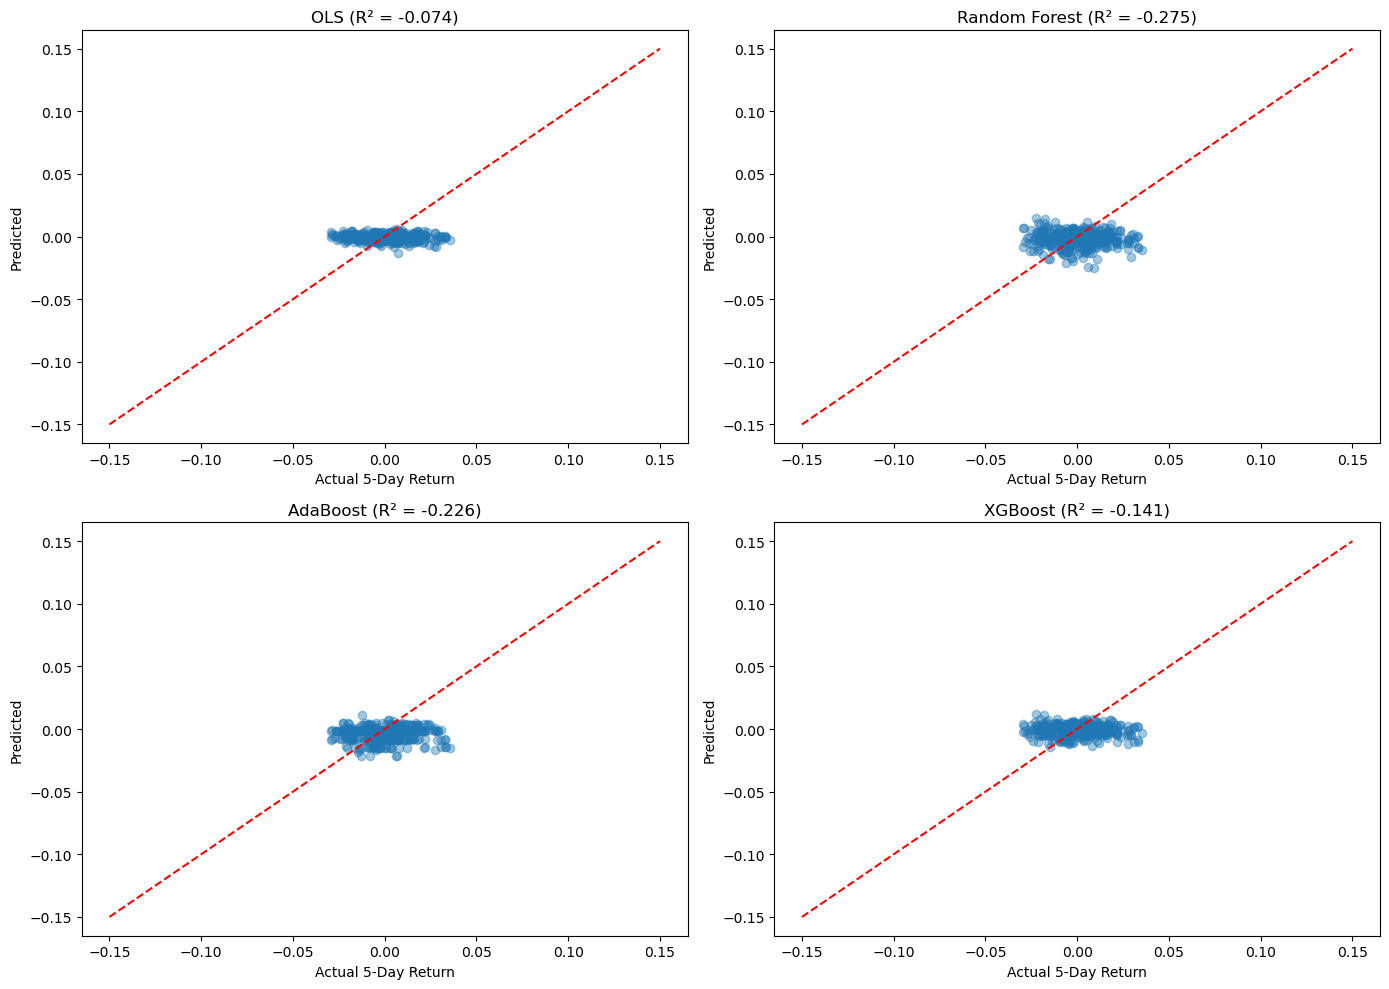

In [26]:
# Actual vs Predicted plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, preds) in zip(axes.flatten(), models.items()):
    ax.scatter(y_test, preds, alpha=0.4)
    ax.plot([-0.15, 0.15], [-0.15, 0.15], 'r--')
    ax.set_xlabel('Actual 5-Day Return')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name} (R² = {r2_score(y_test, preds):.3f})')

plt.tight_layout()
plt.show()

## 11. Cross-Validation

In [27]:
print("5-Fold Cross Validation R² Scores")
print("=" * 50)

rf_scores = cross_val_score(rf_gs.best_estimator_, X_train_scaled, y_train, cv=kf, scoring='r2')
print("Random Forest:", rf_scores.mean().round(4), "+/-", rf_scores.std().round(4))

ada_scores = cross_val_score(ada_model, X_train_scaled, y_train, cv=kf, scoring='r2')
print("AdaBoost:", ada_scores.mean().round(4), "+/-", ada_scores.std().round(4))

xgb_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=kf, scoring='r2')
print("XGBoost:", xgb_scores.mean().round(4), "+/-", xgb_scores.std().round(4))

5-Fold Cross Validation R² Scores
Random Forest: 0.1176 +/- 0.0471
AdaBoost: -0.0169 +/- 0.0373
XGBoost: 0.0624 +/- 0.0239


## 12. Trading Strategy

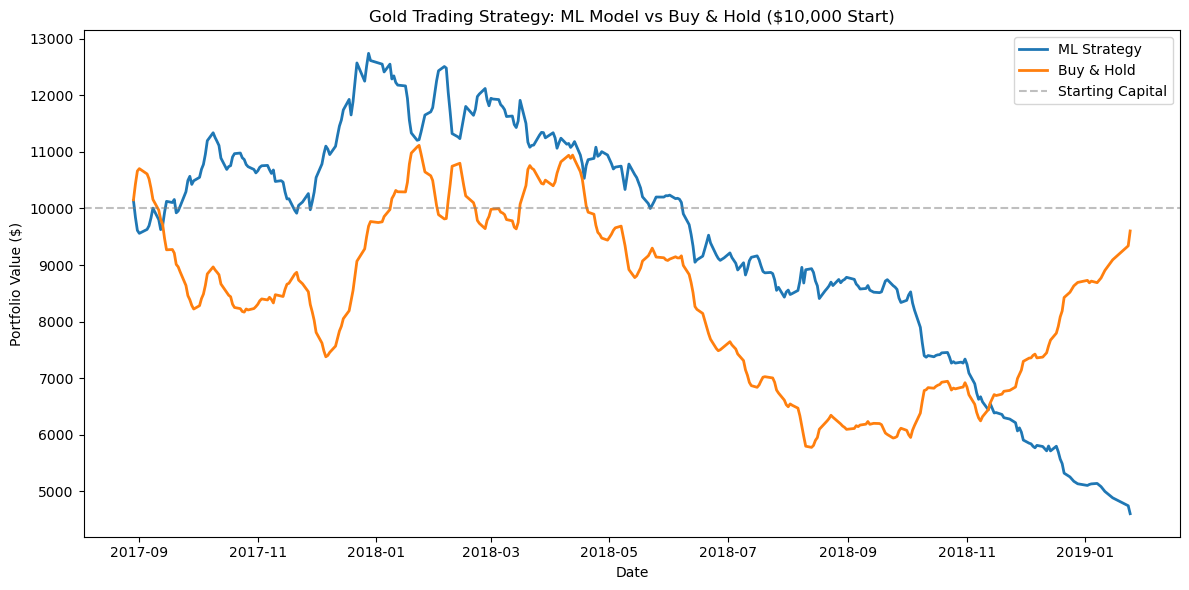

In [28]:
# Use best model predictions on test set
test_df = df.iloc[split_idx:].copy()
test_df['Predicted_Return'] = y_pred_rf  # Use RF (or whichever is best)
test_df['Actual_Return'] = y_test.values
test_df['Signal'] = np.where(test_df['Predicted_Return'] > 0, 1, -1)

# Trading fees
round_trip_cost = 0.001 + 0.0005  # 0.1% commission + 0.05% slippage = 0.15% per trade

# Strategy return (signal * actual return - fees)
test_df['Strategy_Return'] = test_df['Signal'] * test_df['Actual_Return'] - round_trip_cost

# Buy and hold return (baseline)
test_df['BuyHold_Return'] = test_df['Actual_Return']

# Cumulative returns
test_df['Strategy_Cumulative'] = (1 + test_df['Strategy_Return']).cumprod()
test_df['BuyHold_Cumulative'] = (1 + test_df['BuyHold_Return']).cumprod()

# Starting capital
capital = 10000
test_df['Strategy_Value'] = capital * test_df['Strategy_Cumulative']
test_df['BuyHold_Value'] = capital * test_df['BuyHold_Cumulative']

# Plot
plt.figure(figsize=(12, 6))
plt.plot(test_df['Date'], test_df['Strategy_Value'], label='ML Strategy', linewidth=2)
plt.plot(test_df['Date'], test_df['BuyHold_Value'], label='Buy & Hold', linewidth=2)
plt.axhline(y=capital, linestyle='--', color='gray', alpha=0.5, label='Starting Capital')
plt.title('Gold Trading Strategy: ML Model vs Buy & Hold ($10,000 Start)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# Strategy performance metrics
strategy_total = test_df['Strategy_Value'].iloc[-1]
buyhold_total = test_df['BuyHold_Value'].iloc[-1]
strategy_return = (strategy_total / capital - 1) * 100
buyhold_return = (buyhold_total / capital - 1) * 100

# Win rate
test_df['Win'] = (test_df['Signal'] * test_df['Actual_Return'] > 0).astype(int)
win_rate = test_df['Win'].mean() * 100

# Sharpe ratio (annualized)
strategy_daily_returns = test_df['Strategy_Return']
sharpe = strategy_daily_returns.mean() / strategy_daily_returns.std() * np.sqrt(252)

# Max drawdown
cummax = test_df['Strategy_Cumulative'].cummax()
drawdown = (test_df['Strategy_Cumulative'] - cummax) / cummax
max_drawdown = drawdown.min() * 100

print("TRADING STRATEGY PERFORMANCE:")
print(f"Strategy Total Return:  {strategy_return:+.2f}%")
print(f"Buy & Hold Return:      {buyhold_return:+.2f}%")
print(f"Excess Return:          {strategy_return - buyhold_return:+.2f}%")
print(f"Win Rate:               {win_rate:.1f}%")
print(f"Sharpe Ratio:           {sharpe:.2f}")
print(f"Max Drawdown:           {max_drawdown:.2f}%")
print(f"\nStarting Capital:       ${capital:,.0f}")
print(f"Strategy Final Value:   ${strategy_total:,.0f}")
print(f"Buy & Hold Final Value: ${buyhold_total:,.0f}")
print(f"\nTrading Fees Assumed:")
print(f"  Commission: 0.10% per round-trip")
print(f"  Slippage:   0.05% per trade")
print(f"  Total cost: 0.15% per trade")

TRADING STRATEGY PERFORMANCE:
Strategy Total Return:  -53.96%
Buy & Hold Return:      -3.98%
Excess Return:          -49.97%
Win Rate:               49.6%
Sharpe Ratio:           -2.48
Max Drawdown:           -63.86%

Starting Capital:       $10,000
Strategy Final Value:   $4,604
Buy & Hold Final Value: $9,602

Trading Fees Assumed:
  Commission: 0.10% per round-trip
  Slippage:   0.05% per trade
  Total cost: 0.15% per trade


In [30]:
# Signal distribution
print("\nSignal Distribution:")
print(f"  Buy signals:  {(test_df['Signal']==1).sum()} ({(test_df['Signal']==1).mean()*100:.1f}%)")
print(f"  Sell signals: {(test_df['Signal']==-1).sum()} ({(test_df['Signal']==-1).mean()*100:.1f}%)")

# Monthly performance breakdown
test_df['Month'] = test_df['Date'].dt.to_period('M')
monthly = test_df.groupby('Month')['Strategy_Return'].sum() * 100
print(f"\nBest month:  {monthly.idxmax()} ({monthly.max():+.2f}%)")
print(f"Worst month: {monthly.idxmin()} ({monthly.min():+.2f}%)")
print(f"Profitable months: {(monthly > 0).sum()} / {len(monthly)} ({(monthly > 0).mean()*100:.0f}%)")


Signal Distribution:
  Buy signals:  128 (37.5%)
  Sell signals: 213 (62.5%)

Best month:  2017-12 (+20.72%)
Worst month: 2018-11 (-21.45%)
Profitable months: 4 / 18 (22%)


## 13. NLP Feature Analysis — How Sentiment Drives Predictions

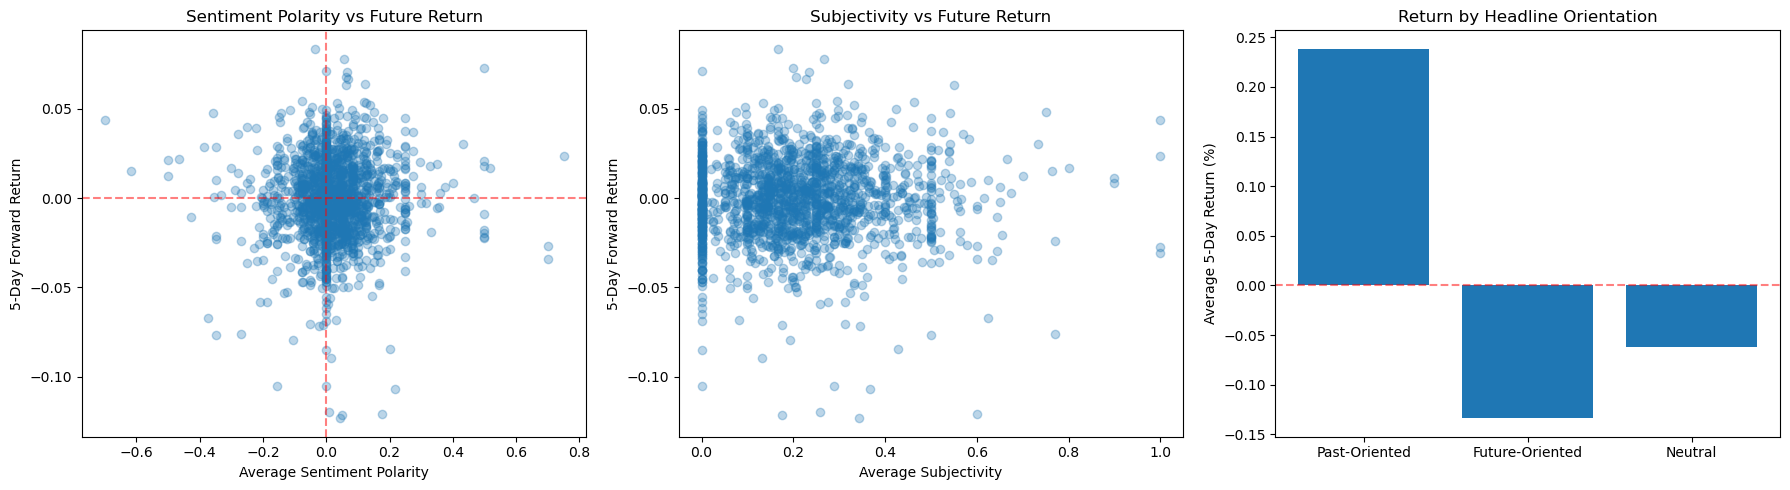

Avg return when sentiment is positive: -0.0135%
Avg return when sentiment is negative: -0.0821%


In [31]:
# Sentiment polarity vs future returns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df['Avg_Polarity'], df['Target_Return_5d'], alpha=0.3)
axes[0].set_xlabel('Average Sentiment Polarity')
axes[0].set_ylabel('5-Day Forward Return')
axes[0].set_title('Sentiment Polarity vs Future Return')
axes[0].axhline(0, linestyle='--', color='red', alpha=0.5)
axes[0].axvline(0, linestyle='--', color='red', alpha=0.5)

axes[1].scatter(df['Avg_Subjectivity'], df['Target_Return_5d'], alpha=0.3)
axes[1].set_xlabel('Average Subjectivity')
axes[1].set_ylabel('5-Day Forward Return')
axes[1].set_title('Subjectivity vs Future Return')

# Past vs Future oriented headlines and returns
past_returns = df[df['Pct_Past'] > 0.5]['Target_Return_5d'].mean()
future_returns = df[df['Pct_Future'] > 0.5]['Target_Return_5d'].mean()
neutral_returns = df[(df['Pct_Past'] <= 0.5) & (df['Pct_Future'] <= 0.5)]['Target_Return_5d'].mean()

axes[2].bar(['Past-Oriented', 'Future-Oriented', 'Neutral'], 
            [past_returns*100, future_returns*100, neutral_returns*100])
axes[2].set_ylabel('Average 5-Day Return (%)')
axes[2].set_title('Return by Headline Orientation')
axes[2].axhline(0, linestyle='--', color='red', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Avg return when sentiment is positive: {df[df['Avg_Polarity']>0]['Target_Return_5d'].mean()*100:.4f}%")
print(f"Avg return when sentiment is negative: {df[df['Avg_Polarity']<0]['Target_Return_5d'].mean()*100:.4f}%")

## 14. Business Insights and Trading Recommendations

In [32]:
# Final summary
print("PROJECT SUMMARY")
print(f"\nDataset: {len(df)} trading days with matched news")
print(f"Features: {len(nlp_features)} NLP + {len(price_features)} price = {len(all_features)} total")
print(f"Target: 5-day forward return")
print(f"\nModel Comparison (Test R²):")
print(f"  OLS:           {r2_score(y_test, y_pred_ols):.4f}")
print(f"  Random Forest: {r2_score(y_test, y_pred_rf):.4f}")
print(f"  AdaBoost:      {r2_score(y_test, y_pred_ada):.4f}")
print(f"  XGBoost:       {r2_score(y_test, y_pred_xgb):.4f}")
print(f"\nTrading Strategy Performance:")
print(f"  Total Return:    {strategy_return:+.2f}%")
print(f"  Buy & Hold:      {buyhold_return:+.2f}%")
print(f"  Win Rate:        {win_rate:.1f}%")
print(f"  Sharpe Ratio:    {sharpe:.2f}")

PROJECT SUMMARY

Dataset: 1703 trading days with matched news
Features: 10 NLP + 8 price = 18 total
Target: 5-day forward return

Model Comparison (Test R²):
  OLS:           -0.0738
  Random Forest: -0.2752
  AdaBoost:      -0.2255
  XGBoost:       -0.1405

Trading Strategy Performance:
  Total Return:    -53.96%
  Buy & Hold:      -3.98%
  Win Rate:        49.6%
  Sharpe Ratio:    -2.48
